In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
# --- EJEMPLO DE USO ---

# Definimos el arquetipo: Un fanático del buen fútbol parejo, que prioriza un poco 
# que caiga en su horario libre después de trabajar.
usuario_ejemplo = {
    "nacionalidad": "Argentina",
    "pesos": {
        "w_nacionalidad": 0.35,
        "w_calidad_elo": 0.30,      # Pesa 30% el nivel general
        "w_paridad_elo": 0.20,      # Pesa 20% que sea peleado
        "w_valor_plantel": 0.15,    # Pesa 15% el valor de mercado
        "w_paridad_valor": 0.10,    # Pesa 10% la paridad económica
        "w_fin_de_semana": 0.05,    # Pesa 5% si es fin de semana
        "w_horario_libre": 0.20     # Pesa 20% que caiga en su agenda
    },
    "horario_libre": {
        0: [18, 19, 20, 21, 22], # Lunes a Viernes libre desde las 18:00
        1: [18, 19, 20, 21, 22],
        2: [18, 19, 20, 21, 22],
        3: [18, 19, 20, 21, 22],
        4: [18, 19, 20, 21, 22],
        5: [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22], # Sábado libre desde mediodía
        6: [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]  # Domingo libre desde mediodía
    }
}

In [55]:
def recomendar_partidos(df_partidos, perfil_usuario):
    """
    Calcula un score de recomendación para cada partido basado en las preferencias
    del usuario y sus horarios disponibles.
    
    Parámetros:
    df_partidos (DataFrame): La matriz de partidos ya escalada.
    perfil_usuario (dict): Diccionario con los pesos y horarios del usuario.
    
    Retorna:
    DataFrame: El dataset original ordenado con la nueva columna 'Score_Recomendacion'.
    """
    
    # Trabajamos sobre una copia para no modificar el dataset original
    df = df_partidos.copy()
    
    # =====================================================================
    # PASO 1: Calcular la característica dinámica (Horario Libre)
    # =====================================================================
    def verificar_disponibilidad(row):
        # 1.1: Extraemos el día y la hora. Se hace el ajuste de zona horaria (ej: UTC-3)
        hora_local = (row['match_hora_utc'] - 3) % 24 
        dia = row['day_of_week_num']
        
        # 1.2: Verificamos si esa hora está en la lista de horas libres para ese día
        horas_libres_del_dia = perfil_usuario['horario_libre'].get(dia, [])
        if hora_local in horas_libres_del_dia:
            return 1.0  # El usuario puede verlo
        return 0.0      # El usuario está ocupado
    
    # 1.3: Aplicamos la función a cada fila creando la columna 'feature_disponibilidad'
    df['feature_disponibilidad'] = df.apply(verificar_disponibilidad, axis=1)

    # =====================================================================
    # PASO 2: Extraer y NORMALIZAR los pesos del diccionario del usuario
    # =====================================================================
    pesos_crudos = perfil_usuario['pesos']
    
    # Sumamos todos los valores (si el usuario puso pesos perfectos sumará 1.0, 
    # pero si sumó de más o de menos, esto lo detecta)
    suma_total = sum(pesos_crudos.values())
    
    # Creamos el diccionario definitivo dividiendo cada peso por la suma total
    pesos = {k: v / suma_total for k, v in pesos_crudos.items()}

    # --- C. Feature de Nacionalidad ---
    pais_usuario = perfil_usuario.get('nacionalidad', '')
    # Da 1.0 si el país juega de local o de visitante, sino 0.0
    df['feature_nacionalidad'] = (
        (df['home_team'] == pais_usuario) | (df['away_team'] == pais_usuario)
    ).astype(float)
    
    # =====================================================================
    # PASO 3: Calcular el Score Final (Producto Punto)
    # =====================================================================
    # Aquí aplicamos la combinación lineal. 
    # NOTA CLAVE PARA LA PARIDAD: Para las variables de "diferencia" (ELO_diff y value_diff), 
    # un valor alto es algo MALO (partido desparejo). Por eso las restamos de 1: (1 - variable).
    # De esta manera, una diferencia cercana a 0 se vuelve un 1 (máxima puntuación).
    
    df['Score_Recomendacion'] = (
        (pesos['w_nacionalidad']  * df['feature_nacionalidad']) +            # Juega su selección
        (pesos['w_calidad_elo']   * df['ELO_match_rating_scaled']) +         # Nivel general del partido
        (pesos['w_paridad_elo']   * (1 - df['ELO_diff_scaled'])) +           # Qué tan parejo es deportivamente
        (pesos['w_valor_plantel'] * df['match_value_scaled']) +              # Cantidad de estrellas/valor
        (pesos['w_paridad_valor'] * (1 - df['match_value_diff_scaled'])) +   # Qué tan parejo es económicamente
        (pesos['w_fin_de_semana'] * df['is_weekend']) +                      # Bonus si se juega sábado/domingo
        (pesos['w_horario_libre'] * df['feature_disponibilidad'])            # Coincidencia con su agenda
    )

    # =====================================================================
    # PASO 4: Clasificación por Categorías (¡NUEVO!)
    # =====================================================================
    def categorizar_partido(score):
        if score >= 0.65:
            return "Imperdible 🌟"
        elif score >= 0.45:
            return "Vale la pena 📺"
        else:
            return "Para ver el resumen 📱"
            
    # Aplicamos la función a la columna de score
    df['Categoria'] = df['Score_Recomendacion'].apply(categorizar_partido)
    
    # =====================================================================
    # PASO 5: Ordenar
    # =====================================================================
    df_recomendado = df.sort_values(by='Score_Recomendacion', ascending=False)
    
    return df_recomendado

In [56]:
matriz_partidos = pd.read_csv("../data/matriz_partidos_scaled.csv", index_col="id_partido")
matriz_partidos

,home_team,away_team,day_of_week_num,is_weekend,ELO_match_rating,ELO_diff,home_value,away_value,match_value,match_value_diff,match_hora_utc,ELO_match_rating_scaled,ELO_diff_scaled,match_value_scaled,match_value_diff_scaled
id_partido,,,,,,,,,,,,,,,
1,Korea Republic,Czechia,4,0,3478,26,143.400,196.425,339.825,53.025,2,0.484417,0.022135,0.469576,0.448777
2,Mexico,South Africa,3,0,3382,334,85.600,52.700,138.300,32.900,19,0.398931,0.423177,0.205817,0.370770
3,Czechia,South Africa,3,0,3250,202,196.425,52.700,249.125,143.725,16,0.281389,0.251302,0.378366,0.613715
4,Mexico,Korea Republic,4,0,3610,106,85.600,143.400,229.000,57.800,1,0.601959,0.126302,0.353639,0.462953
5,South Africa,Korea Republic,3,0,3276,228,52.700,143.400,196.100,90.700,1,0.304541,0.285156,0.308133,0.537336
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,England,Croatia,2,0,3950,90,1315.000,356.300,1671.300,958.700,20,0.904720,0.105469,0.938463,0.930370
69,Panama,England,5,1,3757,283,32.850,1315.000,1347.850,1282.150,21,0.732858,0.356771,0.875099,0.978988
70,Ghana,Panama,2,0,3242,232,295.175,32.850,328.025,262.325,23,0.274265,0.290365,0.459189,0.713904


In [57]:
df_recomendaciones = recomendar_partidos(matriz_partidos, usuario_ejemplo)

df_recomendaciones.head(10)

,home_team,away_team,day_of_week_num,is_weekend,ELO_match_rating,ELO_diff,home_value,away_value,match_value,match_value_diff,match_hora_utc,ELO_match_rating_scaled,ELO_diff_scaled,match_value_scaled,match_value_diff_scaled,feature_disponibilidad,feature_nacionalidad,Score_Recomendacion,Categoria
id_partido,,,,,,,,,,,,,,,,,,,
58,Argentina,Algeria,2,0,3856,370,765.50,227.800,993.300,537.700,1,0.821015,0.470052,0.785198,0.833712,1.0,1.0,0.767928,Imperdible 🌟
56,Argentina,Austria,0,0,3940,286,765.50,259.700,1025.200,505.800,17,0.895815,0.360677,0.794507,0.823495,0.0,1.0,0.654397,Imperdible 🌟
66,Colombia,Portugal,5,1,3959,9,303.95,965.000,1268.950,661.050,23,0.912734,0.000000,0.857331,0.868224,1.0,0.0,0.641183,Vale la pena 📺
60,Jordan,Argentina,6,1,3803,423,18.25,765.500,783.750,747.250,2,0.773820,0.539062,0.715429,0.888711,0.0,1.0,0.624279,Vale la pena 📺
46,Uruguay,Spain,5,1,4057,273,361.10,1271.000,1632.100,909.900,0,1.000000,0.343750,0.931471,0.921635,1.0,0.0,0.613931,Vale la pena 📺
34,Netherlands,Japan,6,1,3865,57,763.00,266.550,1029.550,496.450,20,0.829029,0.062500,0.795754,0.820378,1.0,0.0,0.610025,Vale la pena 📺
53,Norway,Senegal,1,0,3790,34,586.50,464.300,1050.800,122.200,0,0.762244,0.032552,0.801771,0.586762,1.0,0.0,0.580557,Vale la pena 📺
13,Brazil,Morocco,5,1,3805,163,909.20,238.600,1147.800,670.600,22,0.775601,0.200521,0.827775,0.870621,1.0,0.0,0.577541,Vale la pena 📺
31,Netherlands,Sweden,5,1,3680,242,763.00,435.375,1198.375,327.625,17,0.664292,0.303385,0.840476,0.750984,1.0,0.0,0.547840,Vale la pena 📺


🏆 TOP 10 PARTIDOS RECOMENDADOS:
  home_team away_team  Score_Recomendacion      Categoria  match_hora_utc  day_of_week_num
  Argentina   Algeria             0.767928   Imperdible 🌟               1                2
  Argentina   Austria             0.654397   Imperdible 🌟              17                0
   Colombia  Portugal             0.641183 Vale la pena 📺              23                5
     Jordan Argentina             0.624279 Vale la pena 📺               2                6
    Uruguay     Spain             0.613931 Vale la pena 📺               0                5
Netherlands     Japan             0.610025 Vale la pena 📺              20                6
     Norway   Senegal             0.580557 Vale la pena 📺               0                1
     Brazil   Morocco             0.577541 Vale la pena 📺              22                5
Netherlands    Sweden             0.547840 Vale la pena 📺              17                5
     Panama   England             0.542126 Vale la pena 📺 

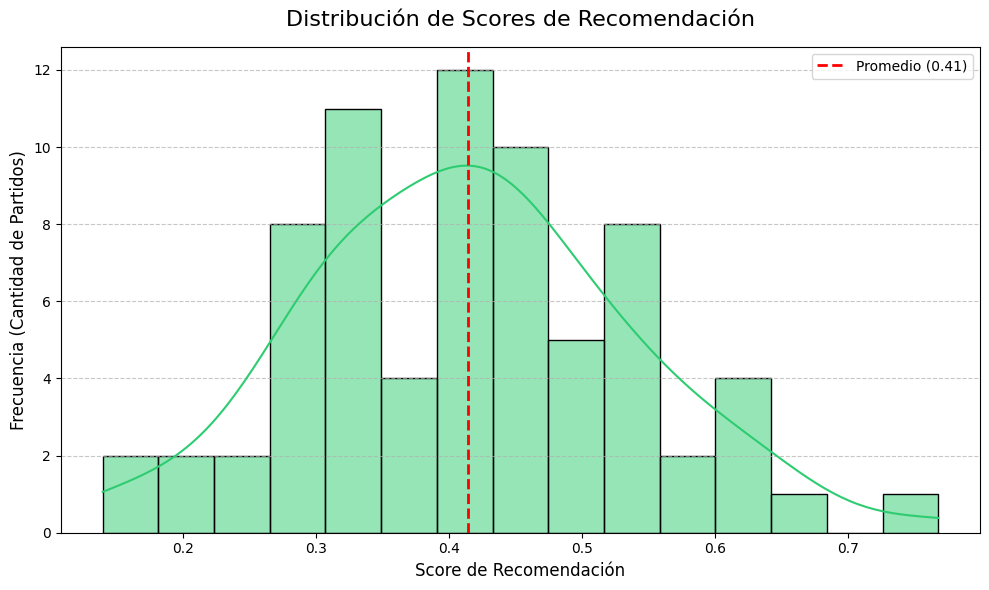

In [58]:
# =====================================================================
# 3. MOSTRAR RESULTADOS Y GRÁFICO
# =====================================================================

# Seleccionamos las columnas más importantes para ver el Top 10
columnas_vista = [
    'home_team', 'away_team', 'Score_Recomendacion', 
    'Categoria','match_hora_utc', 'day_of_week_num'
]

print("🏆 TOP 10 PARTIDOS RECOMENDADOS:")
print(df_recomendaciones[columnas_vista].head(10).to_string(index=False))

# --- Generar el gráfico de distribución ---
plt.figure(figsize=(10, 6))
sns.histplot(
    df_recomendaciones['Score_Recomendacion'], 
    bins=15, 
    kde=True, 
    color='#2ecc71', 
    edgecolor='black'
)

plt.title('Distribución de Scores de Recomendación', fontsize=16, pad=15)
plt.xlabel('Score de Recomendación', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de Partidos)', fontsize=12)

# Línea marcando el promedio
promedio = df_recomendaciones['Score_Recomendacion'].mean()
plt.axvline(promedio, color='red', linestyle='dashed', linewidth=2, label=f'Promedio ({promedio:.2f})')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [59]:
usuario_fanatico = {
    "nacionalidad": "Mexico",
    "pesos": {
        "w_nacionalidad": 100,  # Importancia absoluta
        "w_calidad_elo": 0,
        "w_paridad_elo": 0,
        "w_valor_plantel": 0,
        "w_paridad_valor": 0,
        "w_fin_de_semana": 0,
        "w_horario_libre": 0
    },
    "horario_libre": {
        # Libre las 24hs del día (simulamos que no le importa el horario)
        0: list(range(0, 24)), 1: list(range(0, 24)), 2: list(range(0, 24)),
        3: list(range(0, 24)), 4: list(range(0, 24)), 5: list(range(0, 24)), 
        6: list(range(0, 24))
    }
}

df_recomendaciones = recomendar_partidos(matriz_partidos, usuario_fanatico)
print("🏆 TOP 10 PARTIDOS RECOMENDADOS:")
print(df_recomendaciones[columnas_vista].head(10).to_string(index=False))

🏆 TOP 10 PARTIDOS RECOMENDADOS:
     home_team          away_team  Score_Recomendacion             Categoria  match_hora_utc  day_of_week_num
        Mexico       South Africa                  1.0          Imperdible 🌟              19                3
        Mexico     Korea Republic                  1.0          Imperdible 🌟               1                4
       Czechia             Mexico                  1.0          Imperdible 🌟               1                3
Korea Republic            Czechia                  0.0 Para ver el resumen 📱               2                4
       Czechia       South Africa                  0.0 Para ver el resumen 📱              16                3
  South Africa     Korea Republic                  0.0 Para ver el resumen 📱               1                3
        Canada Bosnia-Herzegovina                  0.0 Para ver el resumen 📱              19                4
   Switzerland Bosnia-Herzegovina                  0.0 Para ver el resumen 📱            

In [60]:
usuario_analista = {
    "nacionalidad": "Argentina",
    "pesos": {
        "w_nacionalidad": 20,    
        "w_calidad_elo": 40,     # Prioriza el alto rendimiento deportivo
        "w_paridad_elo": 20,     # Busca cruces tácticos muy parejos
        "w_valor_plantel": 10,
        "w_paridad_valor": 0,
        "w_fin_de_semana": 0,
        "w_horario_libre": 10    # El horario importa, pero no es excluyente
    },
    "horario_libre": {
        # Durante la semana está ocupado, solo mira fútbol de noche.
        0: [21, 22, 23], 1: [21, 22, 23], 2: [21, 22, 23], 3: [21, 22, 23], 4: [21, 22, 23],
        # El finde está mucho más libre
        5: list(range(12, 24)), 6: list(range(12, 24))
    }
}

df_recomendaciones = recomendar_partidos(matriz_partidos, usuario_analista)
print("🏆 TOP 10 PARTIDOS RECOMENDADOS:")
print(df_recomendaciones[columnas_vista].head(10).to_string(index=False))

🏆 TOP 10 PARTIDOS RECOMENDADOS:
  home_team away_team  Score_Recomendacion      Categoria  match_hora_utc  day_of_week_num
  Argentina   Algeria             0.812915   Imperdible 🌟               1                2
     Jordan Argentina             0.773258   Imperdible 🌟               2                6
  Argentina   Austria             0.765641   Imperdible 🌟              17                0
   Colombia  Portugal             0.750827   Imperdible 🌟              23                5
    Uruguay     Spain             0.724397   Imperdible 🌟               0                5
Netherlands     Japan             0.698687   Imperdible 🌟              20                6
     Norway   Senegal             0.678564   Imperdible 🌟               0                1
     Brazil   Morocco             0.652914   Imperdible 🌟              22                5
     Norway    France             0.635537 Vale la pena 📺              19                4
    England   Croatia             0.634640 Vale la pena 📺 

In [61]:
usuario_casual = {
    "nacionalidad": "",
    "pesos": {
        "w_nacionalidad": 0,
        "w_calidad_elo": 0,
        "w_paridad_elo": 0,
        "w_valor_plantel": 60,   # Solo le importa cuántos millones hay en cancha
        "w_paridad_valor": 0,
        "w_fin_de_semana": 20,   # Prioriza sábados y domingos
        "w_horario_libre": 20    
    },
    "horario_libre": {
        0: [], 1: [], 2: [], 3: [], 4: [], # Lunes a viernes no mira nada
        5: [14, 15, 16, 17, 18, 19],       # Tarde de sábado
        6: [14, 15, 16, 17, 18, 19]        # Tarde de domingo
    }
}
df_recomendaciones = recomendar_partidos(matriz_partidos, usuario_casual)
print("🏆 TOP 10 PARTIDOS RECOMENDADOS:")
print(df_recomendaciones[columnas_vista].head(10).to_string(index=False))

🏆 TOP 10 PARTIDOS RECOMENDADOS:
  home_team     away_team  Score_Recomendacion    Categoria  match_hora_utc  day_of_week_num
    Germany Côte d'Ivoire             0.946584 Imperdible 🌟              20                5
     Panama       England             0.925059 Imperdible 🌟              21                5
Netherlands        Sweden             0.904285 Imperdible 🌟              17                5
     Brazil       Morocco             0.896665 Imperdible 🌟              22                5
    Germany       Curaçao             0.878090 Imperdible 🌟              17                6
Netherlands         Japan             0.877452 Imperdible 🌟              20                6
    Croatia         Ghana             0.796608 Imperdible 🌟              21                5
    Belgium       IR Iran             0.780209 Imperdible 🌟              19                6
    Uruguay         Spain             0.758883 Imperdible 🌟               0                5
      Spain  Saudi Arabia             

In [62]:
usuario_scout = {
    "nacionalidad": "",
    "pesos": {
        "w_nacionalidad": 0,
        "w_calidad_elo": 0,       # No le importan las potencias
        "w_paridad_elo": 50,      # Tiene que ser un partido a muerte y parejo
        "w_valor_plantel": 0,     
        "w_paridad_valor": 50,    # Choque de realidades económicas similares
        "w_fin_de_semana": 0,
        "w_horario_libre": 0
    },
    "horario_libre": {
        # Libre siempre, adapta su vida para ver estos partidos
        0: list(range(0, 24)), 1: list(range(0, 24)), 2: list(range(0, 24)),
        3: list(range(0, 24)), 4: list(range(0, 24)), 5: list(range(0, 24)), 
        6: list(range(0, 24))
    }
}

df_recomendaciones = recomendar_partidos(matriz_partidos, usuario_scout)
print("🏆 TOP 10 PARTIDOS RECOMENDADOS:")
print(df_recomendaciones[columnas_vista].head(10).to_string(index=False))

🏆 TOP 10 PARTIDOS RECOMENDADOS:
     home_team      away_team  Score_Recomendacion    Categoria  match_hora_utc  day_of_week_num
       IR Iran    New Zealand             0.891927 Imperdible 🌟               1                1
    Cabo Verde   Saudi Arabia             0.817087 Imperdible 🌟               0                5
      Scotland        Morocco             0.790736 Imperdible 🌟              22                4
       Algeria        Austria             0.768293 Imperdible 🌟               2                6
Korea Republic        Czechia             0.764544 Imperdible 🌟               2                4
      Paraguay      Australia             0.707541 Imperdible 🌟               2                4
        Mexico Korea Republic             0.705372 Imperdible 🌟               1                4
        Norway        Senegal             0.690343 Imperdible 🌟               0                1
         Egypt        IR Iran             0.682945 Imperdible 🌟               3                